In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('titanic.csv')
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


# 1. Data cleaning on "number" column:

In [3]:
df['number'].unique()

<StringArray>
['5', '3', '6', 'A', '2', '1', '4']
Length: 7, dtype: str

Text(0.5, 1.0, 'Passengers travelling with')

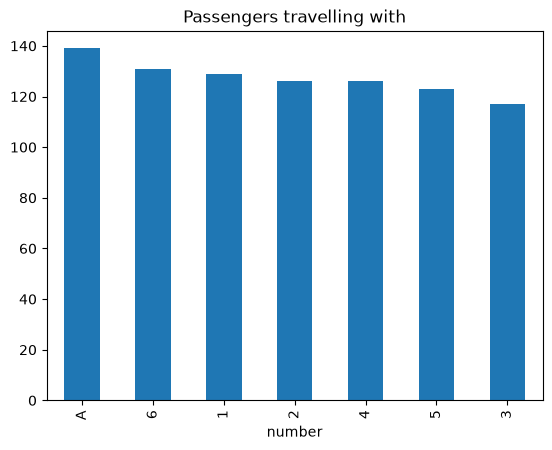

In [4]:
fig= df['number'].value_counts().plot.bar()
fig.set_title('Passengers travelling with')

In [7]:
# Extracting Numerical Part of column-number :
df['number_numerical']= pd.to_numeric(df['number'],errors='coerce',downcast='integer')

# Extracting Categorical Part of column-number :
# np.where(condition, A, B)...If the condition is True, use A; otherwise, use B.
# np.where(condition, value_if_true, value_if_false)
#If condition is True
#       ↓
#use value_if_true
#
#Else
#       ↓
#use value_if_false
df['number_categorical']= np.where(df['number_numerical'].isnull(),df['number'],np.nan)

df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


# 2. Data cleaning on "Cabin" column:

In [8]:
df['Cabin'].unique()

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [9]:
# Extracting numerical part:
df['cabin_num'] = df['Cabin'].str.extract(r'(\d+)')

# Extracting first letter/ categorical part:
df['cabin_cat'] = df['Cabin'].str[0]

# Standard way to extract one or more categorical parts:
#df['Cabin'].str.extract(r'([A-Za-z]+)')

More regex shortcuts: 
Regex	Meaning	Example Match
\d	Digit	5, 9
\D	Not a digit	A, @
\w	Letter, digit, underscore	A, z, 9, _
\W	Not a word character	@, #, -, space
\s	Whitespace	Space, tab, newline
\S	Not whitespace	A, 5, @

Easy way to memorize

Think of the letters:

\d → d = digit
\w → w = word
\s → s = space

And remember:

Lowercase (\d, \w, \s) → match that type.
Uppercase (\D, \W, \S) → match everything except that type.

In [10]:
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


<Axes: xlabel='cabin_cat'>

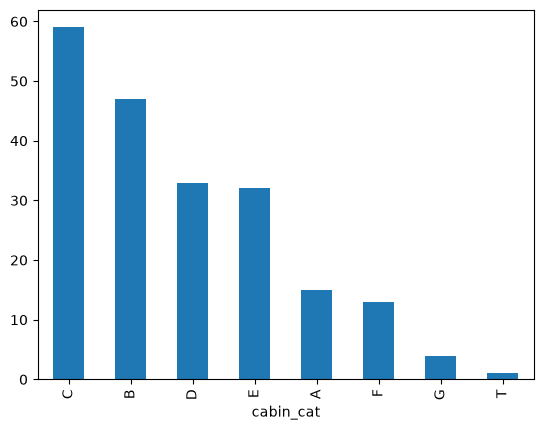

In [11]:
df['cabin_cat'].value_counts().plot(kind='bar')

# 3. Data cleaning on "Ticket" column:

In [12]:
df['Ticket'].unique()

<StringArray>
[       'A/5 21171',         'PC 17599', 'STON/O2. 3101282',
           '113803',           '373450',           '330877',
            '17463',           '349909',           '347742',
           '237736',
 ...
           '349212',           '349217',           '349257',
             '7552', 'C.A./SOTON 34068',  'SOTON/OQ 392076',
           '211536',           '112053',           '111369',
           '370376']
Length: 681, dtype: str

In [13]:
df['Ticket'].isnull().sum()

np.int64(0)

In [14]:
# Extracting the last bit of ticket as number:
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
df['ticket_num'] = pd.to_numeric(df['ticket_num'],errors='coerce',downcast='integer')

# Extracting the first part of ticket as category:
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(),np.nan,df['ticket_cat'])

df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN


In [15]:
df['ticket_cat'].unique()

<StringArray>
[       'A/5',         'PC',   'STON/O2.',          nan,         'PP',
       'A/5.',       'C.A.',      'A./5.',   'SC/Paris',  'S.C./A.4.',
       'A/4.',         'CA',       'S.P.',     'S.O.C.',       'SO/C',
      'W./C.',   'SOTON/OQ',     'W.E.P.',     'STON/O',        'A4.',
          'C', 'SOTON/O.Q.',   'SC/PARIS',     'S.O.P.',       'A.5.',
         'Fa',        'CA.',       'LINE',     'F.C.C.',        'W/C',
      'SW/PP',      'SCO/W',       'P/PP',         'SC',      'SC/AH',
        'A/S',        'A/4',       'WE/P',    'S.W./PP',  'S.O./P.P.',
       'F.C.',   'SOTON/O2', 'S.C./PARIS', 'C.A./SOTON']
Length: 44, dtype: str